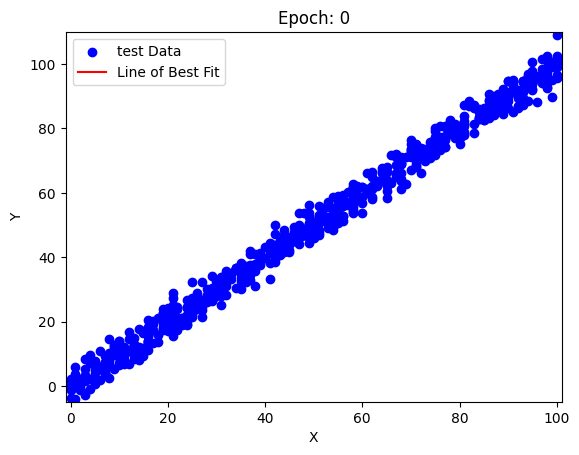

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from typing import Tuple, List
import sklearn.linear_model
from matplotlib.animation import FuncAnimation

# Download and read the data.
def read_train_data(filename: str) -> pd.DataFrame:
    df = pd.read_csv(filename)
    return df
pass

def read_test_data(filename: str) -> pd.DataFrame:
    df = pd.read_csv(filename)
    return df
pass


# Prepare your input data and labels
def prepare_data(df_train: pd.DataFrame, df_test: pd.DataFrame) -> tuple:
    train_data = df_train.dropna().drop(columns=['y']).to_numpy()
    train_label = df_train.dropna().drop(columns=['x']).to_numpy()

    test_data = df_test.dropna().drop(columns=['y']).to_numpy()
    test_label = df_test.dropna().drop(columns=['x']).to_numpy()

    return train_data, train_label, test_data, test_label
pass

# Implement LinearRegression class
class LinearRegression:   
    def __init__(self, learning_rate=0.01, epoches=1000):        
        self.learning_rate = learning_rate
        self.iterations    = epoches
        self.W = None
        self.b = None
        self.history = []
          
    # Function for model training         
    def fit(self, X, Y):
        n_samples, n_features = X.shape
         # weight initialization
        self.W = np.random.randn(n_features,1)
        self.b = np.random.randn()
        
        for _ in range(self.iterations):
            error = 0
            for idx, x_i in enumerate(X):

                linear_output = np.dot(x_i, self.W) + self.b

                update = self.learning_rate * (Y[idx] - linear_output)
                
                self.W += update * x_i
                self.b += update
                self.history.append(self.predict(X))

        return self.W, self.b

      
    # output      
    def predict(self, X):
        #y_pred = np.zeros((X.size,1))
        #print('y_pred',y_pred.size,y_pred.shape)
        #for i in range(X.size):
        y_pred = np.dot(X, self.W) + self.b
        #y_predictions = pd.DataFrame(y_pred).to_numpy()
        #print(y_pred)
        return y_pred

# Calculate and print the mean square error of your prediction
def MSE(y_test, pred):
    squared_errors = (y_test - pred) ** 2

    # Calculate the mean squared error
    mse = np.mean(squared_errors)

    return mse

def animate_line(X, history, test_y):
    fig, ax = plt.subplots()
    ax.scatter(X, test_y, label='test Data', color='blue')

    line, = ax.plot([], [], label='Line of Best Fit', color='red')

    ax.set_xlim(np.min(X) - 1, np.max(X) + 1)
    ax.set_ylim(np.min(test_y) - 1, np.max(test_y) + 1)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()
    title = ax.set_title("Epoch: 0")
    def update(epoch):
        y_pred = history[epoch].flatten()
        X_flat = X.copy().flatten()
        title.set_text(f"Epoch: {epoch + 1}")
        line.set_data(X_flat, y_pred)
        return line,

    ani = FuncAnimation(fig, update, frames=len(history), interval=200, repeat=False)
    plt.show()
    return ani



if __name__ == "__main__":
   
    data_path_train   = "./train2.csv"
    data_path_test    = "./test.csv"
    df_train, df_test = read_train_data(data_path_train), read_test_data(data_path_test)


    train_X, train_y, test_X, test_y = prepare_data(df_train, df_test)
    r = LinearRegression(learning_rate=0.0001, epoches=2)
    r.fit(train_X, train_y)

    #print(df_train.head())
    #print(df_test.head())

    # Make prediction with test set
    preds = r.predict(test_X)

    # Calculate and print the mean square error of your prediction
    mean_square_error = MSE(test_y, preds)
    #print(mean_square_error) # I added this

    # plot your prediction and labels, you can save the plot and add in the report
    # plt.scatter(test_X,test_y, label='data')
    # plt.plot(test_X, preds)
    # plt.legend()
    # plt.show()

    ani = animate_line(train_X, r.history, train_y)
    ani.save('best_fit.gif', writer='pillow', fps=50)

    
